# Overfitting and Underfitting

<details>
<summary><strong>1. What is Overfitting and Underfitting?</strong></summary>

The goal of ML is not only to perform well on training data, but to **generalize well to unseen data**.

* **Underfitting** → model is too simple and cannot learn the important patterns.
* **Good fit** → model learns the important patterns and generalizes well.
* **Overfitting** → model is too complex and learns noise from the training data.

```text
Underfitting       Good Fit        Overfitting
    ↓                 ↓                ↓
Too simple       Good complexity   Too complex
High error       Low error         Low train error
                                   High test error
```

</details>

<details>
<summary><strong>2. Underfitting</strong></summary>

Underfitting means the model has **not learned enough**.

### Signs

$$
Train\ Error \approx Test\ Error
$$

but both errors are **high**.

### Causes

* Model is too simple
* Not enough useful features
* Too much regularization
* Poor feature representation

### Solutions

* Use a more complex model
* Add useful features
* Reduce regularization
* Improve feature engineering

</details>

<details>
<summary><strong>3. Overfitting</strong></summary>

Overfitting means the model learns the training data **too closely**, including noise.

### Signs

$$
Train\ Error \ll Test\ Error
$$

### Causes

* Model is too complex
* Too many features
* Too little training data
* Noisy data
* Not enough regularization

### Solutions

* Get more data
* Reduce model complexity
* Remove irrelevant features
* Use regularization
* Use cross-validation

</details>

<details>
<summary><strong>4. What is Regularization?</strong></summary>

Regularization helps prevent overfitting by **penalizing large model weights**.

Instead of minimizing only:

$$
Loss
$$

we minimize:

$$
Loss + \lambda \times Penalty
$$

where $\lambda$ controls the **strength of regularization**.

```text
Small λ → weak regularization → more complex model

Large λ → strong regularization → simpler model
```

Too much regularization can cause **underfitting**.

</details>

<details>
<summary><strong>5. Ridge Regression (L2)</strong></summary>

Ridge adds an L2 penalty:

$$
Loss + \lambda\sum w_j^2
$$

It **shrinks coefficients** toward zero but usually does not make them exactly zero.

### Use Ridge when:

* Many features are useful
* Features are correlated
* You want to reduce overfitting without removing features

```text
Ridge
  ↓
Shrink weights
  ↓
Keep most/all features
```

</details>

<details>
<summary><strong>6. Lasso Regression (L1)</strong></summary>

Lasso adds an L1 penalty:

$$
Loss + \lambda\sum |w_j|
$$

It can make some coefficients exactly zero:

$$
w_j = 0
$$

So Lasso can perform **feature selection**.

### Use Lasso when:

* You have many features
* Some features may be irrelevant
* You want a simpler model

```text
Lasso
  ↓
Shrink weights
  ↓
Some weights → 0
  ↓
Feature selection
```

</details>

<details>
<summary><strong>7. Elastic Net</strong></summary>

Elastic Net combines **L1 + L2**:

$$
Loss + \lambda
\left[
\alpha\sum|w_j|
+
(1-\alpha)\sum w_j^2
\right]
$$

It gives you both:

* **L1** → feature selection
* **L2** → coefficient shrinkage

It can be useful when you have **many correlated features**.

</details>

<details>
<summary><strong>8. Ridge vs Lasso vs Elastic Net</strong></summary>

| Algorithm       | Main idea                | Useful when                 |
| --------------- | ------------------------ | --------------------------- |
| **Ridge**       | Shrink weights           | Most features are useful    |
| **Lasso**       | Shrink + remove features | Many irrelevant features    |
| **Elastic Net** | L1 + L2                  | Many features + correlation |

Simple rule:

```text
Most features useful
       ↓
     Ridge

Many irrelevant features
       ↓
     Lasso

Irrelevant + correlated features
       ↓
  Elastic Net
```

These are **starting points**, not absolute rules. Compare them using validation.

</details>

<details>
<summary><strong>9. How to Choose the Best One?</strong></summary>

Don't choose based only on the algorithm name.

Try:

```text
Ridge
Lasso
Elastic Net
```

and tune their hyperparameters using **cross-validation**.

For example:

$$
\lambda \in \{0.001,0.01,0.1,1,10\}
$$

For Elastic Net, also tune $\alpha$:

$$
\alpha \in [0,1]
$$

Remember:

```text
Training data
      ↓
Cross-validation
      ↓
Choose model + hyperparameters
      ↓
Final evaluation on test data
```

The **test set should not be used to choose $\lambda$ or $\alpha$**.

</details>

<details>
<summary><strong>10. Final Mental Model</strong></summary>

```text
Underfitting
Too simple
    ↓
Increase complexity
Add useful features
Reduce regularization


Overfitting
Too complex
    ↓
Reduce complexity
Remove irrelevant features
Add regularization


Regularization
    ↓
Ridge → L2 → Shrink weights

Lasso → L1 → Feature selection

Elastic Net → L1 + L2
```

The main goal is:

$$
\boxed{\text{Good generalization on unseen data}}
$$

</details>


In [25]:
import numpy as np
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score,mean_squared_error
import matplotlib.pyplot as plt

In [26]:
x=np.array([[1],[2],[3],[4]])
# scikit-learn generally represents a single target variable as a 1D array
y=np.array([2,4,6,8])

# linear regression
lin_reg=LinearRegression()
lin_reg.fit(x,y)
y_pred_lin=lin_reg.predict(x)


# ridge regression
ridge=Ridge(alpha=100)
ridge.fit(x,y)
y_pred_ridge=ridge.predict(x)


# lasso regression
lasso=Lasso(alpha=100)
lasso.fit(x,y)
y_pred_lasso=lasso.predict(x)

In [27]:
print("mean of y :",np.sum(y)/len(y))
print("LinearRegression :")
print("mse :",mean_squared_error(y,y_pred_lin))
print("w:",lin_reg.coef_)
print("b :",lin_reg.intercept_)
print("yhat:",y_pred_lin)
print("y:",y)
print("==========================")
print("RidgeRegression :")
print("mse :",mean_squared_error(y,y_pred_ridge))
print("w:",ridge.coef_)
print("b :",ridge.intercept_)
print("yhat:",y_pred_ridge)
print("y:",y)
print("==========================")

print("LassoRegression :")
print("mse :",mean_squared_error(y,y_pred_lasso))
print("w:",lasso.coef_)
print("b :",lasso.intercept_)
print("yhat:",y_pred_lasso)
print("y:",y)

mean of y : 5.0
LinearRegression :
mse : 0.0
w: [2.]
b : 0.0
yhat: [2. 4. 6. 8.]
y: [2 4 6 8]
RidgeRegression :
mse : 4.53514739229025
w: [0.0952381]
b : 4.761904761904762
yhat: [4.85714286 4.95238095 5.04761905 5.14285714]
y: [2 4 6 8]
LassoRegression :
mse : 5.0
w: [0.]
b : 5.0
yhat: [5. 5. 5. 5.]
y: [2 4 6 8]


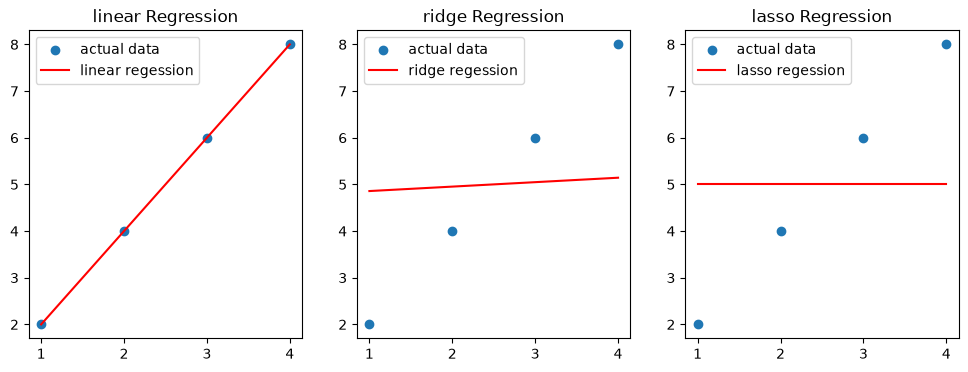

In [28]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(x,y,label='actual data')
plt.plot(x,y_pred_lin,c='r',label="linear regession")
plt.title("linear Regression")
plt.legend()
plt.subplot(1,3,2)
plt.scatter(x,y,label='actual data')
plt.plot(x,y_pred_ridge,c='r',label="ridge regession")
plt.title("ridge Regression")
plt.legend()
plt.subplot(1,3,3)
plt.scatter(x,y,label='actual data')
plt.plot(x,y_pred_lasso,c='r',label="lasso regession")
plt.title("lasso Regression")
plt.legend()

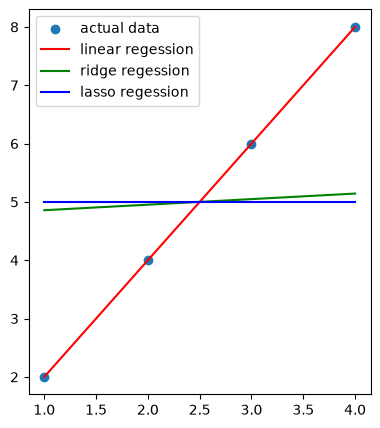

In [29]:
# Ridge can't be horizonatal line 
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.scatter(x,y,label='actual data')
plt.plot(x,y_pred_lin,c='r',label="linear regession")
plt.plot(x,y_pred_ridge,c='g',label="ridge regession")
plt.plot(x,y_pred_lasso,c='b',label="lasso regession")
plt.legend()